# PCA Project: Abalone Dataset
## Goal: Understand and implement PCA from scratch

---
## Phase 1: Setup & Data Loading

# 1. Import Libraries

**Why?** We need specialized tools for mathematical operations and data processing.

**How?** Import standard data science libraries: `numpy` (matrices/linear algebra), `pandas` (dataframes), `matplotlib/seaborn` (visualization), and `scipy` (statistics).

**In Code:** Load necessary modules into the working environment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
# Ignore warnings containing "batch_size"
warnings.filterwarnings("ignore", message=".*batch_size.*")

# 2. Load Data

**Why?** The dataset is available as a CSV file and needs to be loaded into memory for analysis.

**How?** Use `pd.read_csv` to parse the comma-separated values into a Pandas DataFrame.

**In Code:** Read `abalone.csv` from the Data folder.

In [2]:
# Load data
abalone = pd.read_csv(r"Data/abalone.csv")

# 3. First Overview

**Why?** We need to understand the structure, column names, and data types to choose the right preprocessing steps.

**How?** `head()` shows the first 5 rows, `info()` shows data types and memory usage.

**In Code:** Display raw data and metadata.

In [3]:
# First look at the data
display(abalone.head())
print(f"Shape of dataset: {abalone.shape}")
print("Data Types:")
print(abalone.info())

,Sex,Length,Diameter,Height,Whole weight,Shucked weight,Viscera weight,Shell weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


Shape of dataset: (4177, 9)
Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 3   Height          4177 non-null   float64
 4   Whole weight    4177 non-null   float64
 5   Shucked weight  4177 non-null   float64
 6   Viscera weight  4177 non-null   float64
 7   Shell weight    4177 non-null   float64
 8   Rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB
None


---
## Phase 2: Exploratory Data Analysis (EDA)

# 4. Descriptive Statistics

**Why?** Get a sense of the distributions, means, and spread of the data.

**How?** `describe()` calculates metrics like Mean, Std, Min, Max, and Quartiles for numeric columns.

**In Code:** Statistical summary of the dataset.

In [4]:
# Descriptive statistics
print(abalone.describe())

            Length     Diameter       Height  Whole weight  Shucked weight  \
count  4177.000000  4177.000000  4177.000000   4177.000000     4177.000000   
mean      0.523992     0.407881     0.139516      0.828742        0.359367   
std       0.120093     0.099240     0.041827      0.490389        0.221963   
min       0.075000     0.055000     0.000000      0.002000        0.001000   
25%       0.450000     0.350000     0.115000      0.441500        0.186000   
50%       0.545000     0.425000     0.140000      0.799500        0.336000   
75%       0.615000     0.480000     0.165000      1.153000        0.502000   
max       0.815000     0.650000     1.130000      2.825500        1.488000   

       Viscera weight  Shell weight        Rings  
count     4177.000000   4177.000000  4177.000000  
mean         0.180594      0.238831     9.933684  
std          0.109614      0.139203     3.224169  
min          0.000500      0.001500     1.000000  
25%          0.093500      0.130000     8.

# 5. Check for Missing Values

**Why?** PCA is a purely mathematical method and cannot handle missing values (NaN). These would need to be replaced or removed.

**How?** Check for null values with `isnull().sum()`.

**In Code:** Ensure data quality.

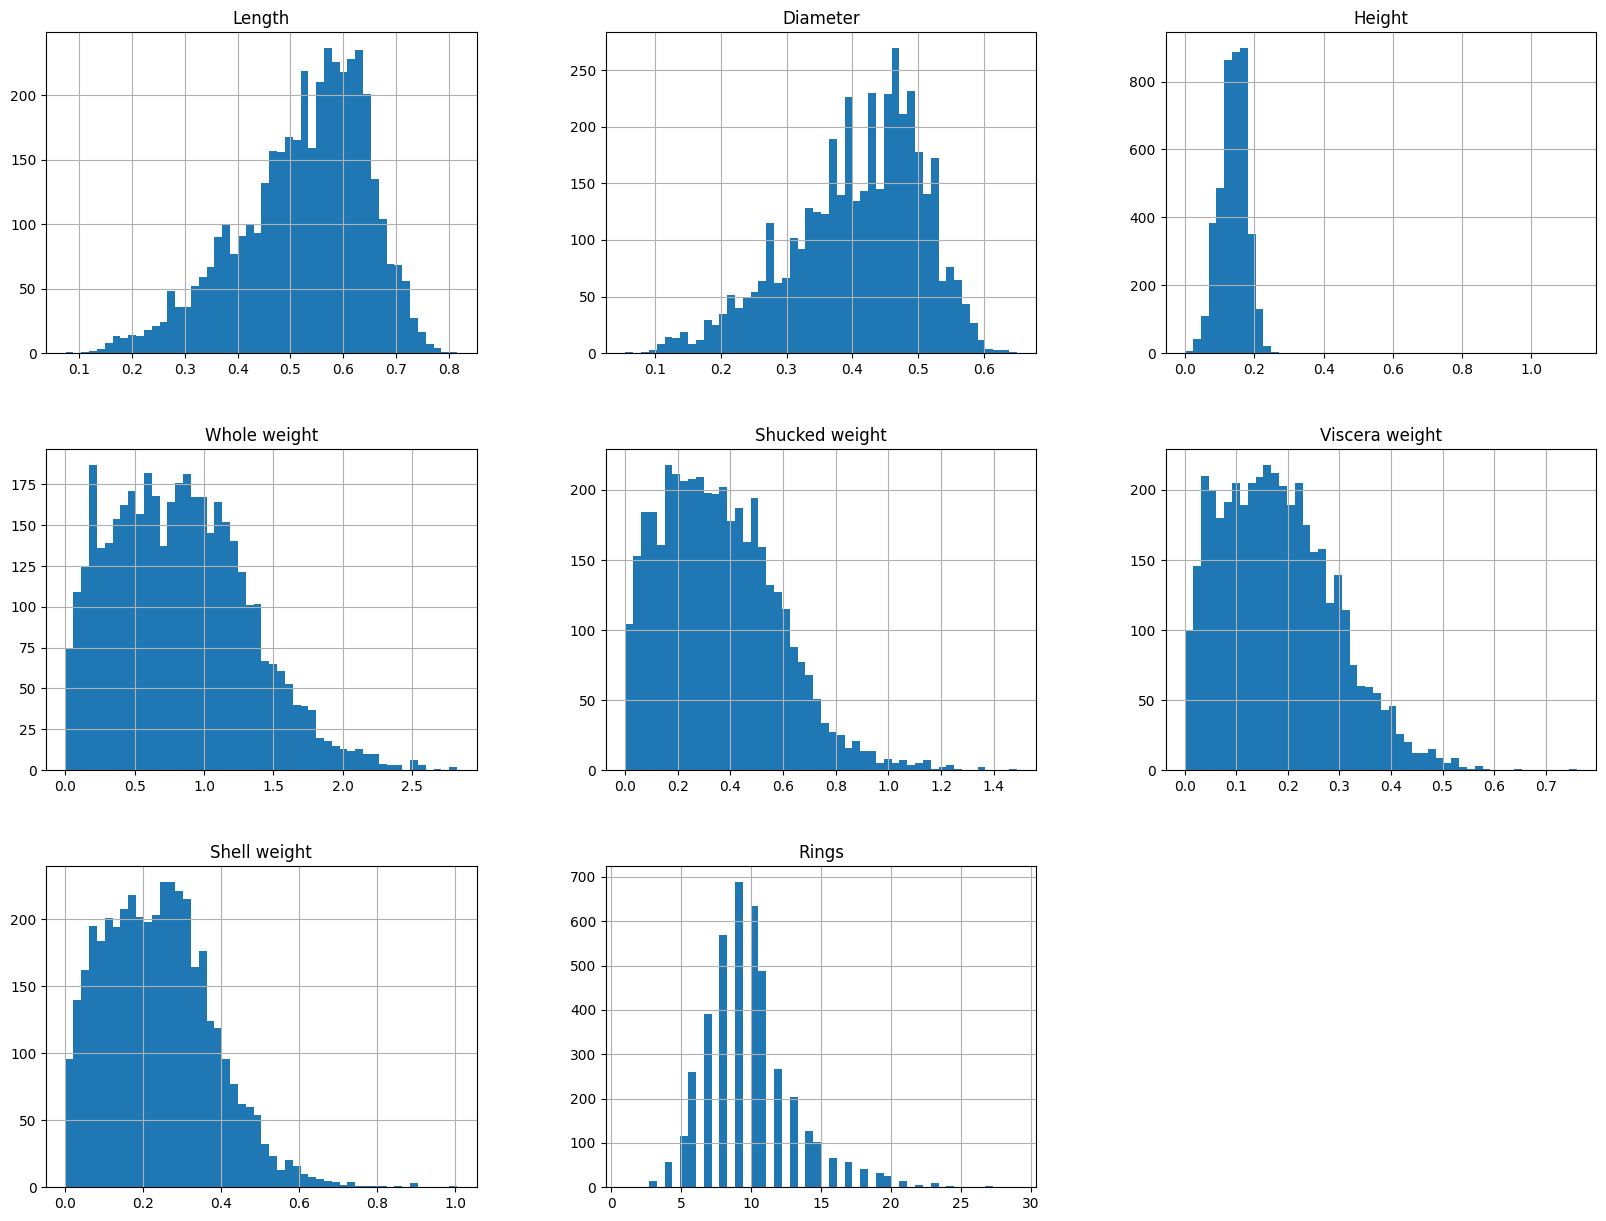

In [5]:
# Create histograms
abalone.hist(bins=50, figsize=(20,15))
plt.show()

In [6]:
# Check for missing values
print (abalone.isnull().sum())

Sex               0
Length            0
Diameter          0
Height            0
Whole weight      0
Shucked weight    0
Viscera weight    0
Shell weight      0
Rings             0
dtype: int64


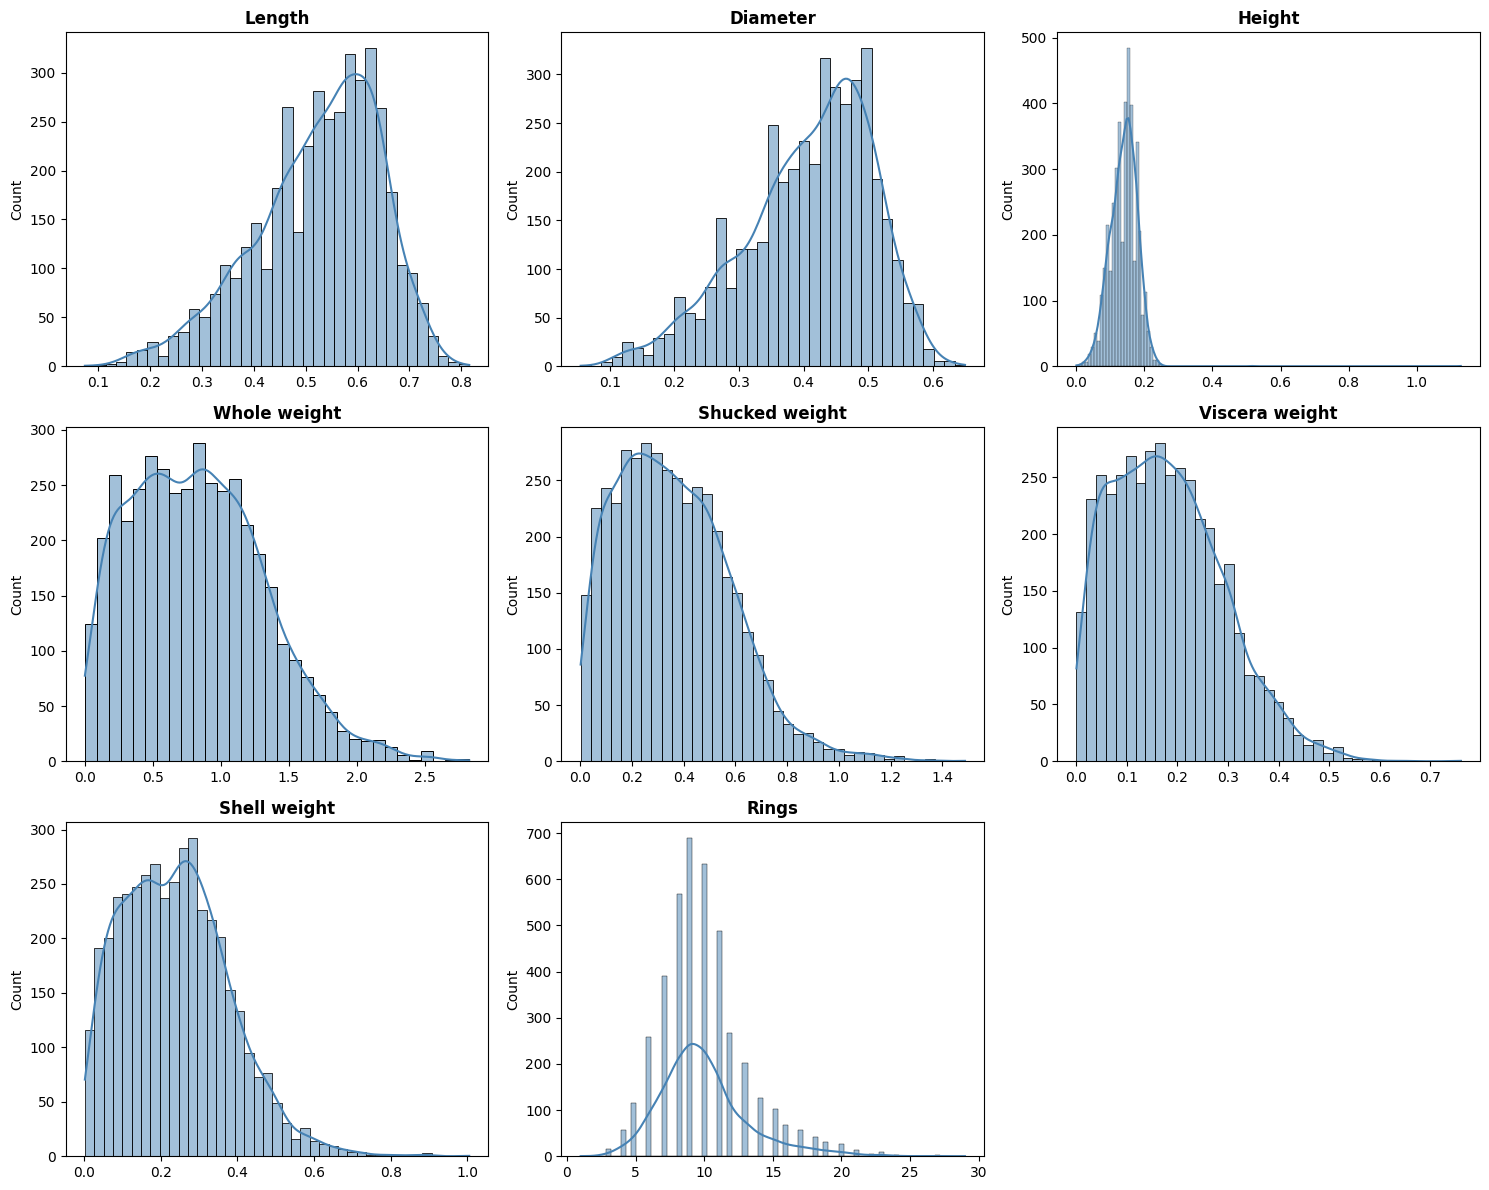

In [7]:
# Select numeric features
numeric_cols = abalone.select_dtypes(include=['number']).columns
# Erstelle ein Grid aus einzelnen Plots
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
# Jeden Plot einzeln erstellen -> Garantiert eigene Achsen!
for i, col in enumerate(numeric_cols):
    sns.histplot(data=abalone, x=col, kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('')
    
# Leere Subplots ausblenden
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

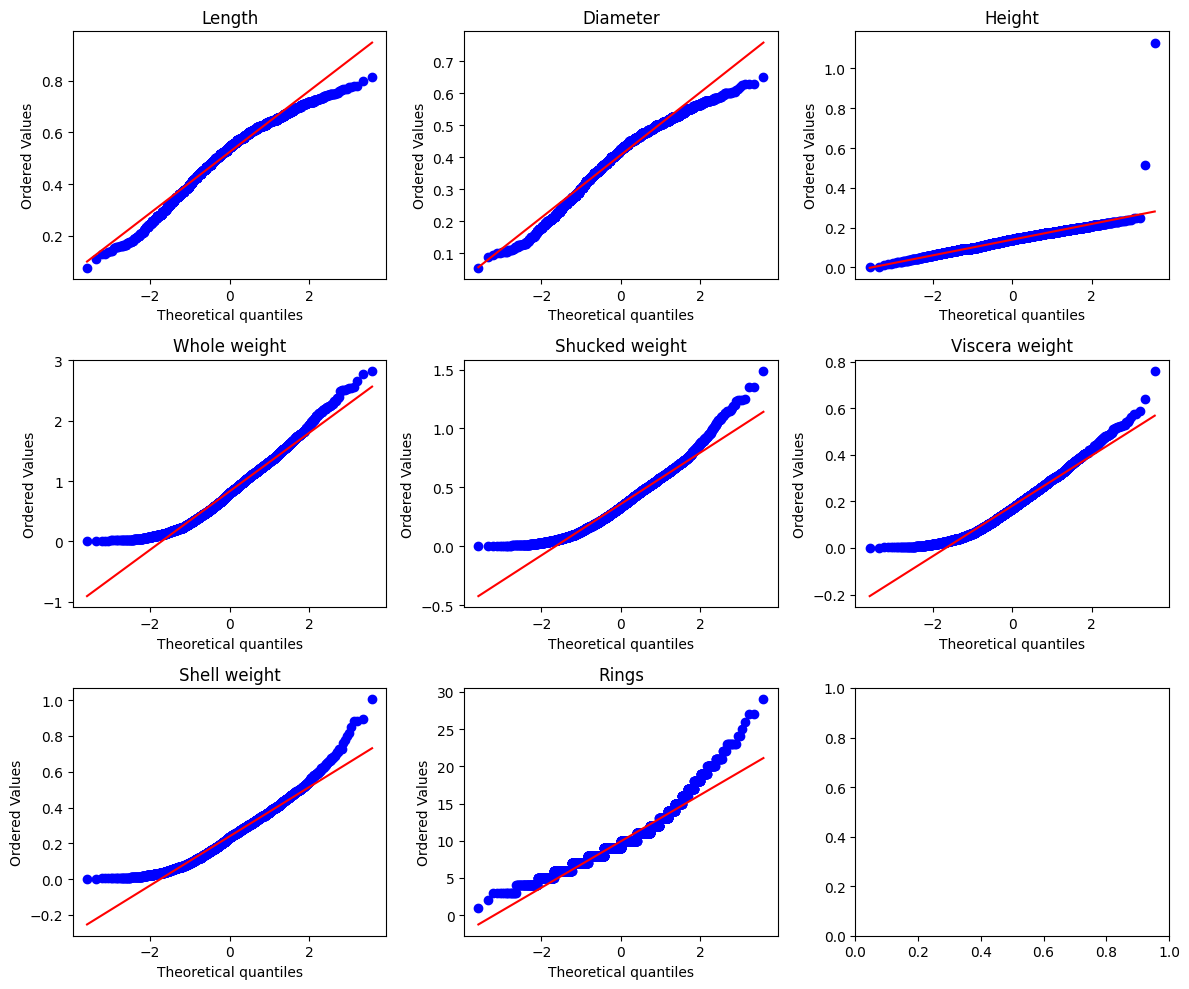

In [8]:
# Q-Q Plots

# Create a figure with 3x3 grid of subplots (9 total)
# figsize sets the overall size in inches (width, height)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

# Flatten the 2D array of axes into 1D for easier indexing
# Before: [[ax0,ax1,ax2], [ax3,ax4,ax5], [ax6,ax7,ax8]]
# After:  [ax0, ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8]
axes = axes.flatten()

# Loop through each numeric column with its index
# enumerate gives us: (0,'Length'), (1,'Diameter'), (2,'Height'), ...
for i, col in enumerate(numeric_cols):
    # Create Q-Q plot for this column on the i-th subplot
    stats.probplot(abalone[col], plot=axes[i])
    # Set the title of this subplot to the column name
    axes[i].set_title(col)

# Adjust spacing between subplots to prevent overlap
plt.tight_layout()
# Display the figure
plt.show()
#Length, Diameter and Height show a normal distribution
#whole weight,shucked weight and viscera weight dont seem to be normal distributed
    

In [9]:

# D'Agostino-Pearson Test - better for large samples
for col in numeric_cols:
    stat, p = stats.normaltest(abalone[col])
    result = "Normal" if p > 0.05 else "Not normal"
    print(f"{col}: p={p:.2e} = {result}")

print (stat)
print (p)

Length: p=2.61e-53 = Not normal
Diameter: p=5.82e-49 = Not normal
Height: p=0.00e+00 = Not normal
Whole weight: p=1.48e-38 = Not normal
Shucked weight: p=7.53e-73 = Not normal
Viscera weight: p=8.58e-47 = Not normal
Shell weight: p=1.99e-57 = Not normal
Rings: p=2.30e-177 = Not normal
813.4491787063884
2.300144867340782e-177


In [10]:
#height has some weird outliers that we should remove
#before:

abalone.drop(abalone[abalone["Height"] >0.4].index, inplace=True)
print (f"new shape: {abalone.shape}")

new shape: (4175, 9)


In [11]:
# encode sex - Kategorische Variable (M/F/I) enkodieren
abalone["Sex"] = abalone["Sex"].map({"M": 0, "F": 1, "I": 2})
print(abalone.head())

   Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
0    0   0.455     0.365   0.095        0.5140          0.2245   
1    0   0.350     0.265   0.090        0.2255          0.0995   
2    1   0.530     0.420   0.135        0.6770          0.2565   
3    0   0.440     0.365   0.125        0.5160          0.2155   
4    2   0.330     0.255   0.080        0.2050          0.0895   

   Viscera weight  Shell weight  Rings  
0          0.1010         0.150     15  
1          0.0485         0.070      7  
2          0.1415         0.210      9  
3          0.1140         0.155     10  
4          0.0395         0.055      7  


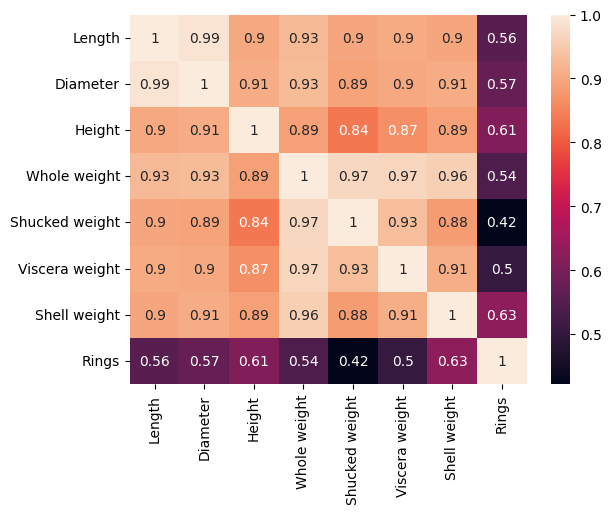

In [12]:
# correlation analysis - Korrelationsmatrix & Heatmap
sns.heatmap(abalone.drop(columns='Sex').corr(), annot=True)
#exclude sex column 
plt.show()

# Correlation matrix: high values between features = redundancy (good for PCA)
# Shell weight has best correlation with Rings (0.63) = best predictor for age

---
## Phase 3: Prepare Data for PCA

In [13]:
# select numeric features 
abalone_num = abalone.select_dtypes(include=["int64", "float64"])
print(abalone_num.head())

   Sex  Length  Diameter  Height  Whole weight  Shucked weight  \
0    0   0.455     0.365   0.095        0.5140          0.2245   
1    0   0.350     0.265   0.090        0.2255          0.0995   
2    1   0.530     0.420   0.135        0.6770          0.2565   
3    0   0.440     0.365   0.125        0.5160          0.2155   
4    2   0.330     0.255   0.080        0.2050          0.0895   

   Viscera weight  Shell weight  Rings  
0          0.1010         0.150     15  
1          0.0485         0.070      7  
2          0.1415         0.210      9  
3          0.1140         0.155     10  
4          0.0395         0.055      7  


In [14]:
# standardize data 
abalone_standardized = (abalone - abalone.mean()) / abalone.std()
print(abalone_standardized.head())

        Sex    Length  Diameter    Height  Whole weight  Shucked weight  \
0 -1.154380 -0.574307 -0.431886 -1.148095     -0.641735       -0.607518   
1 -1.154380 -1.448693 -1.439641 -1.278002     -1.230479       -1.171308   
2  0.053524  0.050254  0.122379 -0.108842     -0.309101       -0.463187   
3 -1.154380 -0.699220 -0.431886 -0.368655     -0.637654       -0.648111   
4  1.261428 -1.615243 -1.540417 -1.537815     -1.272313       -1.216412   

   Viscera weight  Shell weight     Rings  
0       -0.726131     -0.638037  1.570908  
1       -1.205436     -1.212906 -0.909864  
2       -0.356382     -0.206886 -0.289671  
3       -0.607446     -0.602108  0.020426  
4       -1.287603     -1.320693 -0.909864  


---
## Phase 4: Understand PCA Mathematics
Here we implement PCA step by step with NumPy

### 1. Data Standardization & Covariance Matrix

**Why standardize?**
PCA is sensitive to the scaling of the data. Features with large value ranges (e.g. weight) would dominate the analysis. Therefore, we have already z-standardized the data (mean = 0, std = 1): `abalone_standardized`.

**The Covariance Matrix ($\Sigma$)**
Now we calculate the covariance matrix. It describes how the features vary together (correlate).
Mathematically, this is calculated from the standardized data matrix $X$:

$$ \Sigma = \frac{1}{n-1} X^T X $$

The result is a $d \times d$ matrix (d = number of features) that is symmetric.

In [15]:
# covariance matrix - Calculate covariance matrix (manually with NumPy)
# IMPORTANT: We use the standardized data (abalone_standardized), not the raw numbers!
abalone_cov = np.cov(abalone_standardized.T)
print(abalone_cov)

[[ 1.         -0.44855272 -0.45802689 -0.45198512 -0.46097803 -0.44066462
  -0.45439409 -0.44530408 -0.35187965]
 [-0.44855272  1.          0.98680396  0.89983447  0.92537163  0.89818395
   0.90309062  0.89764827  0.55682719]
 [-0.45802689  0.98680396  1.          0.90608582  0.92553718  0.89338478
   0.89976848  0.90527118  0.57479244]
 [-0.45198512  0.89983447  0.90608582  1.          0.88771153  0.83639963
   0.86571013  0.88897977  0.60963374]
 [-0.46097803  0.92537163  0.92553718  0.88771153  1.          0.96938577
   0.96631087  0.95538496  0.54085938]
 [-0.44066462  0.89818395  0.89338478  0.83639963  0.96938577  1.
   0.93186848  0.88268096  0.42144214]
 [-0.45439409  0.90309062  0.89976848  0.86571013  0.96631087  0.93186848
   1.          0.907603    0.50423415]
 [-0.44530408  0.89764827  0.90527118  0.88897977  0.95538496  0.88268096
   0.907603    1.          0.62781544]
 [-0.35187965  0.55682719  0.57479244  0.60963374  0.54085938  0.42144214
   0.50423415  0.62781544  1. 

### 2. Eigendecomposition

We are now looking for the 'principal axes' of the data. These are the directions in which the data has the greatest variance (information).
Mathematically we solve the **eigenvalue problem** for the covariance matrix $\Sigma$:

$$ \Sigma v = \lambda v $$

*   **Eigenvector ($v$)**: Indicates the direction of the new axis (principal component).
*   **Eigenvalue ($\lambda$)**: Indicates the magnitude of the variance along this axis.

![PCA Covariance and Eigenvectors](pca_covariance.png)

High Eigenvalue = Much Information.
Low Eigenvalue = Little Information (Noise).

In [16]:
# eigenvalues eigenvectors - Calculate eigenvalues & eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(abalone_cov)
print("Eigenvalues:\n", eigenvalues)
print("\nEigenvectors:\n", eigenvectors)

Eigenvalues:
 [7.08309223e+00 7.76826747e-01 6.65028596e-01 1.88626616e-01
 1.23313067e-01 8.13572396e-02 6.26995759e-02 1.26459173e-02
 6.41001021e-03]

Eigenvectors:
 [[-2.00367589e-01  8.34598808e-01  5.12162554e-01  1.00790110e-02
   8.97286524e-04 -2.87046238e-02 -1.80296599e-03  7.58354464e-03
  -2.62940471e-04]
 [ 3.61664031e-01  1.08682811e-01 -1.38951502e-02 -4.42105767e-01
   4.08415787e-01  5.59181749e-02  7.88920204e-02 -6.96644239e-01
   1.64056616e-02]
 [ 3.62838813e-01  8.67127435e-02  5.05842471e-03 -4.43458858e-01
   3.68214166e-01  1.19959787e-01  5.51401045e-02  7.14935878e-01
  -1.33663616e-03]
 [ 3.51910480e-01  2.42744236e-02  9.41280216e-02 -4.48565297e-01
  -7.66911907e-01 -2.48683473e-01 -1.23612825e-01 -1.41918093e-02
   4.46934682e-03]
 [ 3.67468513e-01  1.34635533e-01 -8.01282686e-02  3.23169054e-01
  -1.49080330e-02  3.45373633e-02 -1.08559442e-01  1.00422463e-02
   8.50106058e-01]
 [ 3.51787016e-01  2.07184777e-01 -2.26475613e-01  3.10971583e-01
   1.60183

### 3. Sorting Principal Components (Feature Ranking)

**Why sort?**
Not all directions are equally important. The eigenvalues tell us how much variance (information) is in each direction.
We want to reduce dimensions by keeping only the *most important* directions.
Therefore, we sort the eigenvectors in descending order by their eigenvalues.

*   Highest Eigenvalue $\rightarrow$ PC1 (Most Important Component)
*   Second Highest Eigenvalue $\rightarrow$ PC2
*   ...

In [17]:
# sort components - Sort by variance
# We use argsort to get the indices from sorting
idx = eigenvalues.argsort()[::-1]

eigenvalues_sorted = eigenvalues[idx]
eigenvectors_sorted = eigenvectors[:, idx]

print("Sorted Eigenvalues:", eigenvalues_sorted)
print("Sorted Eigenvectors:", eigenvectors_sorted)

Sorted Eigenvalues: [7.08309223e+00 7.76826747e-01 6.65028596e-01 1.88626616e-01
 1.23313067e-01 8.13572396e-02 6.26995759e-02 1.26459173e-02
 6.41001021e-03]
Sorted Eigenvectors: [[-2.00367589e-01  8.34598808e-01  5.12162554e-01  1.00790110e-02
   8.97286524e-04 -2.87046238e-02 -1.80296599e-03  7.58354464e-03
  -2.62940471e-04]
 [ 3.61664031e-01  1.08682811e-01 -1.38951502e-02 -4.42105767e-01
   4.08415787e-01  5.59181749e-02  7.88920204e-02 -6.96644239e-01
   1.64056616e-02]
 [ 3.62838813e-01  8.67127435e-02  5.05842471e-03 -4.43458858e-01
   3.68214166e-01  1.19959787e-01  5.51401045e-02  7.14935878e-01
  -1.33663616e-03]
 [ 3.51910480e-01  2.42744236e-02  9.41280216e-02 -4.48565297e-01
  -7.66911907e-01 -2.48683473e-01 -1.23612825e-01 -1.41918093e-02
   4.46934682e-03]
 [ 3.67468513e-01  1.34635533e-01 -8.01282686e-02  3.23169054e-01
  -1.49080330e-02  3.45373633e-02 -1.08559442e-01  1.00422463e-02
   8.50106058e-01]
 [ 3.51787016e-01  2.07184777e-01 -2.26475613e-01  3.10971583e-01

### 4. Explained Variance Ratio

**How important is each component?**
We want to know what percentage of the original information (total variance) is contained in each principal component.

$$ \text{Explained Variance Ratio} = \frac{\lambda_i}{\sum_{j=1}^{d} \lambda_j} $$

This helps us decide how many dimensions we want to keep (e.g. "We keep 95% of information").

In [18]:
# explained variance - Explained variance per component
explained_variance = (eigenvalues_sorted / np.sum(eigenvalues_sorted)*100)
print (explained_variance)
# Component 1 explains 78% of the variance, component 2 explains 8.6%, which together explain over 87%, meaning it's enough for a 2D plot
 # we take the first two eigenvectors as our projection matrix
projection_matrix = eigenvectors_sorted[:, :2]
print (projection_matrix)

[7.87010248e+01 8.63140830e+00 7.38920662e+00 2.09585129e+00
 1.37014519e+00 9.03969329e-01 6.96661955e-01 1.40510192e-01
 7.12223356e-02]
[[-0.20036759  0.83459881]
 [ 0.36166403  0.10868281]
 [ 0.36283881  0.08671274]
 [ 0.35191048  0.02427442]
 [ 0.36746851  0.13463553]
 [ 0.35178702  0.20718478]
 [ 0.35816227  0.1428897 ]
 [ 0.3602378   0.05708763]
 [ 0.23816018 -0.44586523]]


---
## Phase 5: Implement PCA yourself

### 3. Data Projection

The last step is the transformation of the original data into the new coordinate system.
To do this, we multiply our data matrix $X$ by the matrix of the selected eigenvectors $W$ (feature matrix).

$$ Z = X \cdot W $$

![PCA Projection Concept](pca_projection.png)

The result $Z$ are the so-called **Principal Components** (Scores).

In [19]:
# project data - Project data onto new axes
abalone_pca = abalone_standardized.dot(projection_matrix)
abalone_pca.columns = ['PC1', 'PC2']
print (abalone_pca.head())

print("Old Dimensions:", abalone_standardized.shape)
print("Neue Dimensionen:", abalone_pca.shape) #  (4175, 2) insteas od 4175, 9


        PC1       PC2
0 -1.102462 -2.144044
1 -3.214323 -1.520903
2 -0.534135 -0.013058
3 -1.199937 -1.436243
4 -3.986101  0.429309
Old Dimensions: (4175, 9)
Neue Dimensionen: (4175, 2)


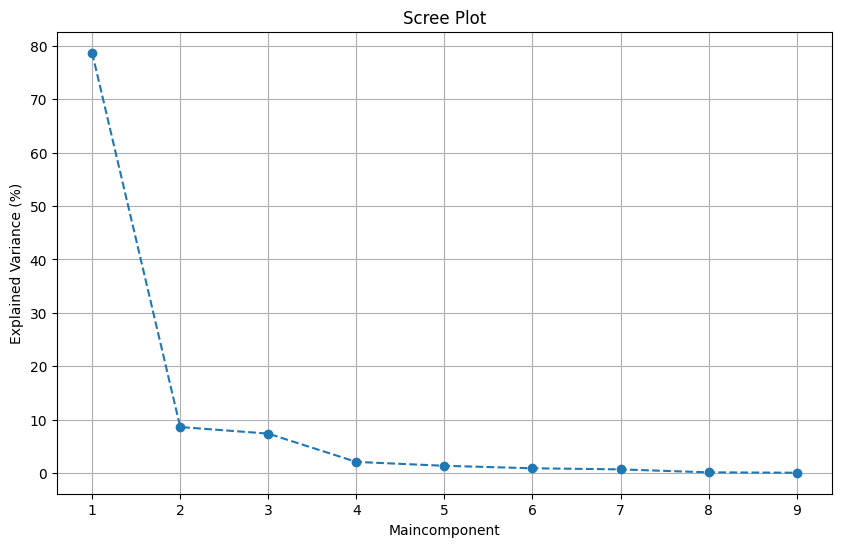

In [20]:
# scree plot - Visualize variance proportion
plt.figure(figsize=(10, 6))
# We have 9 components (number of features)
r = range(1, len(explained_variance) + 1)
plt.plot(r, explained_variance, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Maincomponent')
plt.ylabel('Explained Variance (%)')
plt.grid(True)
plt.show()

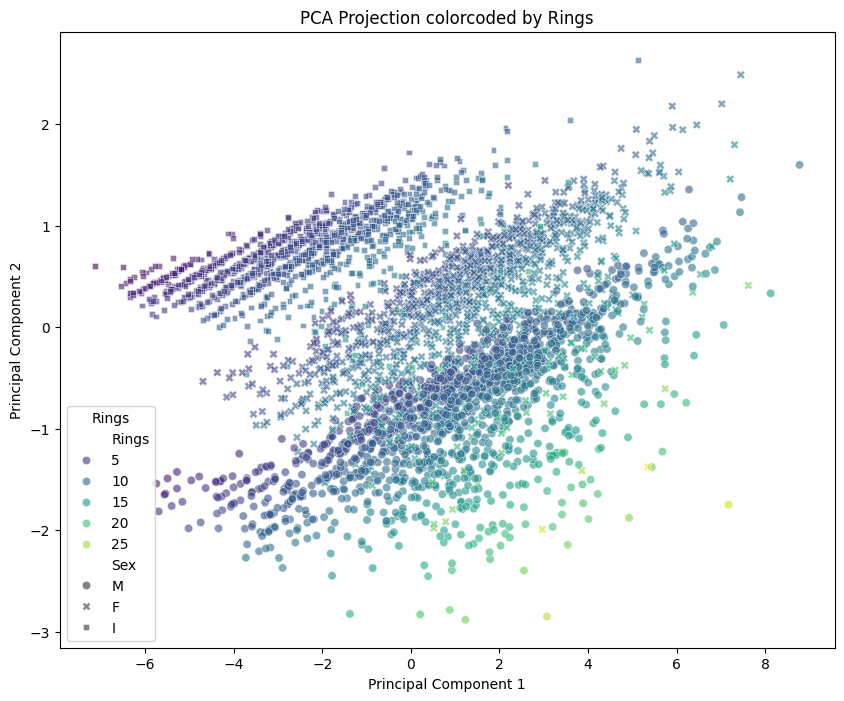

In [21]:
# Map numbers back to letters for the legend
sex_labels = abalone['Sex'].map({0: 'M', 1: 'F', 2: 'I'})

plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    data=abalone_pca, 
    hue=abalone['Rings'], 
    style=sex_labels,        # Here we use the letters
    palette='viridis', 
    alpha=0.6
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection colorcoded by Rings")
plt.legend(title='Rings')
plt.show()

---
## Phase 6: Comparison with Scikit-Learn

# 15. Comparison with Scikit-Learn

**Why?** Validation of our manual calculation and use of efficient standard tools for practice.

**How?** Use of the `PCA` class from `sklearn.decomposition`. It does exactly the same internally (often via SVD).

**In Code:** Application of the standard implementation for comparison.

In [22]:
# sklearn pca - Apply sklearn.decomposition.PCA
from sklearn.decomposition import PCA
# Build "Machine" that keeps only the 2 best components
pca_sklearn = PCA(n_components=2)
# Train machine (fit) AND transform data (transform)
# Fit: Machine learns covariance, eigenvalues etc. and stores them in 'pca_sklearn'
# Transform: Machine spits out the new data (abalone_pca_sklearn)
abalone_pca_sklearn = pca_sklearn.fit_transform(abalone_standardized)
# Comparison of Results
print("Manually explained variance (first 2):", explained_variance[:2])
# Ausgabe: [78.70, 8.63]
# -> These are our calculations: PC1 explains ~78.7% of the info, PC2 ~8.6%.
print("Sklearn explained variance:", pca_sklearn.explained_variance_ratio_ * 100)
# Ausgabe: [78.70, 8.63]
# -> The ".explained_variance_ratio_" property belongs to the MACHINE (pca_sklearn),
#    because it "understood" and stored it during learning.
#    The result is identical (Proof: We calculated correctly!)

Manually explained variance (first 2): [78.70102478  8.6314083 ]
Sklearn explained variance: [78.70102478  8.6314083 ]


---
## Phase 7: ML Model (Bonus)
Simple model to predict age (Rings)

Rings
9     689
10    633
8     567
11    487
7     391
12    267
6     259
13    203
14    126
5     115
15    103
16     67
17     58
4      57
18     42
19     32
20     26
3      15
21     14
23      9
22      6
24      2
27      2
1       1
29      1
26      1
2       1
25      1
Name: count, dtype: int64


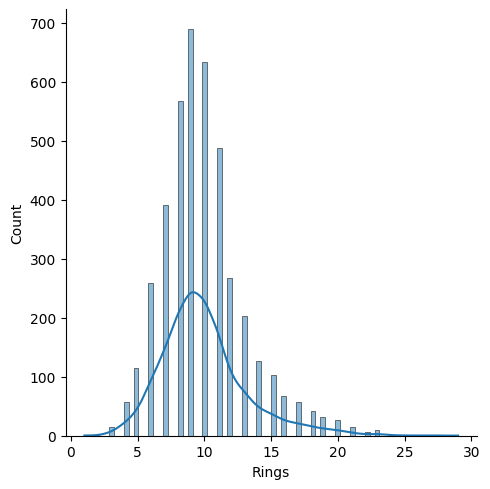

In [23]:
#Plot the Age (Rings) to see the ditribution
print (abalone ["Rings"].value_counts())
sns.displot(abalone ["Rings"], kde=True)

In [24]:
#import libaries
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.metrics import mean_squared_error, r2_score, classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestClassifier

In [25]:
#Standarize the data
x=abalone.drop ("Rings", axis=1)
y = abalone["Rings"]


scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [26]:
# train test split - Split Data
# We split the data: 80% for learning (Train), 20% for testing (Test)
# random_state=42 ensures we always get the same split (reproducible)
X_train, X_test, y_train, y_test = train_test_split(x_scaled, y, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print('Training sample of scaled independent variables:\n',  X_train) # training sample (independent variables)
print('Training sample of target variable:\n',  y_train) # training sample (independent variables)
print('Test sample of scaled independent variables:\n',  X_test) # training sample (independent variables)
print('Test sample of target variable:\n',  y_test) # training sample (independent variables)

Train shape: (3340, 8)
Test shape: (835, 8)
Training sample of scaled independent variables:
 [[ 1.26157862 -0.40780647 -0.5327257  ... -0.47677535 -0.81752539
  -0.70998058]
 [-1.15451805  1.46610245  1.58381336 ...  2.18914672  1.94451401
   2.16470652]
 [ 1.26157862 -0.15795194 -0.17996919 ... -0.41587866 -0.35185924
  -0.48000561]
 ...
 [-1.15451805  0.00861774 -0.07918162 ... -0.42264496 -0.3062057
  -0.393765  ]
 [ 1.26157862  0.46668436  0.12239353 ... -0.13846037 -0.71708759
  -0.09551621]
 [ 0.05353029  0.59161162  0.67672519 ...  0.84716395  0.46077384
   0.23147944]]
Training sample of target variable:
 1272     8
1746    10
2519     7
1281     9
3697    12
        ..
3446     8
466     12
3094     9
3774     9
860      6
Name: Rings, Length: 3340, dtype: int64
Test sample of scaled independent variables:
 [[ 0.05353029 -0.0746671   0.12239353 ... -0.35047109 -0.48881987
  -0.17097675]
 [ 0.05353029 -0.15795194 -0.28075676 ... -0.2963407   0.08641478
  -0.49437905]
 [ 1.2615

## Theory: Why we use Linear Regression
To test if PCA preserves information correctly, we intentionally use a **simple linear model** and not complex methods like Decision Trees.
**The Comparison (Analogy):**
**Linear Regression is like a ruler **: It checks whether the data is nicely arranged in a linear fashion ("sorted"). Since PCA only rotates the data, this is the fairest test.
**Decision Tree is like a thick rulebook **: It learns complex "if-then" rules. It could still extract patterns even from poor PCA data (overfitting) and would give us a false impression that the PCA performed better than it actually did.
**Our Goal**: We want to see how much information (R²) we lose when reducing from 8 features to 2.

In [27]:


# 1. Baseline Model (All Features)
# ---------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)
print(r2_score(y_test, model.predict(X_test)))

0.5657616770018377


In [28]:
# pca model - Linear Regression with PCA Features
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(abalone_pca_sklearn, y, test_size=0.2, random_state=42)
print("PCA Train shape:", X_train_pca.shape) 
print ("PCA test shape:", X_test_pca.shape)

PCA Train shape: (3340, 2)
PCA test shape: (835, 2)


In [29]:
# evaluate - Compare MSE, R², MAE
model = LinearRegression()
model.fit(X_train_pca, y_train_pca)
print(r2_score(y_test_pca, model.predict(X_test_pca)))

0.5921384547946317


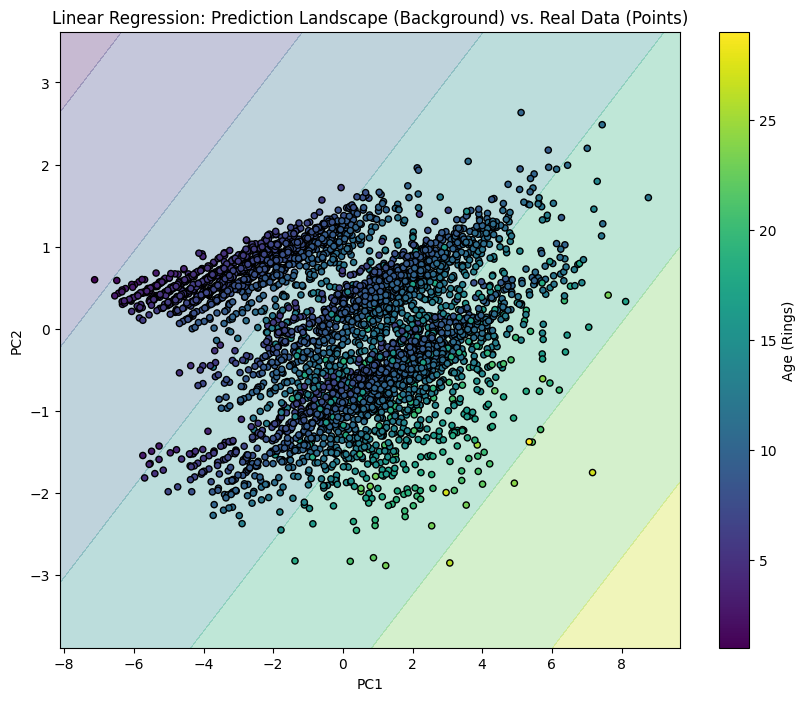

In [30]:
# 1. We create a grid (Meshgrid) over the entire plot area
x_min, x_max = abalone_pca_sklearn[:, 0].min() - 1, abalone_pca_sklearn[:, 0].max() + 1
y_min, y_max = abalone_pca_sklearn[:, 1].min() - 1, abalone_pca_sklearn[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 2. We let the model estimate the age for every point on this grid
# ravel() turns the grid into a long list for the model
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape) # Zurück in Gitter-Form für den Plot

# 3. Plotting
plt.figure(figsize=(10, 8))

# The Background (The Model Prediction)
# contourf paints areas: Dark = Model says "Young", Light = Model says "Old"
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')

# The real data points on top
plt.scatter(abalone_pca_sklearn[:, 0], abalone_pca_sklearn[:, 1], c=y, cmap='viridis', edgecolor='k', s=20)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Linear Regression: Prediction Landscape (Background) vs. Real Data (Points)')
plt.colorbar(label='Age (Rings)')
plt.show()

## Strategy Change: From Regression to Classification
So far we tried to predict the **exact age** (e.g., "9.5 years"). This is extremely difficult and often leads to inaccurate results ($R^2 \approx 0.5$).
**The Solution: Binning (Grouping)**
Instead of the exact number, in practice we are often only interested in: *"Is the mussel young, middle-aged, or old?"*
*   We divide the rings into 3 groups: **Young (0-8)**, **Middle (9-10)**, **Old (11+)**.
*   This makes it easier for the model to recognize robust patterns.



In [ ]:
# ---------------------------------------------------------
# 1. Start: Create Categories ("Binning")
# ---------------------------------------------------------
# We define the boundaries (walls) for our bins:
# Bin 1: 0 to 8 Rings
# Bin 2: 8 to 10 Rings (Most animals are here!)
# Bin 3: 10 to 30 Rings
bins = [0, 8, 10, 30]
# The labels (names) we stick on the 3 bins
group_names = ['young', 'middle', 'old']
# pd.cut does the work:
# It takes column 'y' (Rings/Numbers) and throws each value into the matching bin.
# So the number "9" becomes the word "Middle".
y_bins = pd.cut(y, bins, labels=group_names)
# ---------------------------------------------------------
# 2. Split: Split Data
# ---------------------------------------------------------
# We split data again into Training (Learning) and Test (Checking).
# Input (X): Our PCA data ("abalone_pca_sklearn") -> These are the questions.
# Output (y): Our NEW categories ("y_bins") -> These are the answers.
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    abalone_pca_sklearn,  # Die PCA-Daten
    y_bins,               # The new groups (Young/Middle/Old)
    test_size=0.2,        # Keep 20% for testing
    random_state=42       # So we always get the same result
)
# ---------------------------------------------------------
# 3. The Model: Random Forest Classifier
# ---------------------------------------------------------
# We found a "Council of Experts" (Random Forest).
# n_estimators=200: We ask 200 individual decision trees for their opinion (Majority vote).
# max_depth=7:      Each tree is allowed to drill max 7 questions deep (prevents memorizing data).
rfc_grouped = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=7)
# Training: The 200 trees look at training data and learn rules.
rfc_grouped.fit(X_train_c, y_train_c)
# Prediction: Now the trees must guess for the Test Data (which they have never seen).
y_pred_c = rfc_grouped.predict(X_test_c)
# ---------------------------------------------------------
# 4. Grading (Evaluation)
# ---------------------------------------------------------
# How often was the council right? (Percentage)
print("Test Accuracy:", accuracy_score(y_test_c, y_pred_c))
# Detailed Report: How well were "Young", "Middle", and "Old" recognized?
print(classification_report(y_test_c, y_pred_c))




Test Accuracy: 0.8023952095808383
              precision    recall  f1-score   support

      middle       0.69      0.83      0.75       276
         old       0.85      0.77      0.81       275
       young       0.91      0.80      0.85       284

    accuracy                           0.80       835
   macro avg       0.81      0.80      0.80       835
weighted avg       0.82      0.80      0.81       835



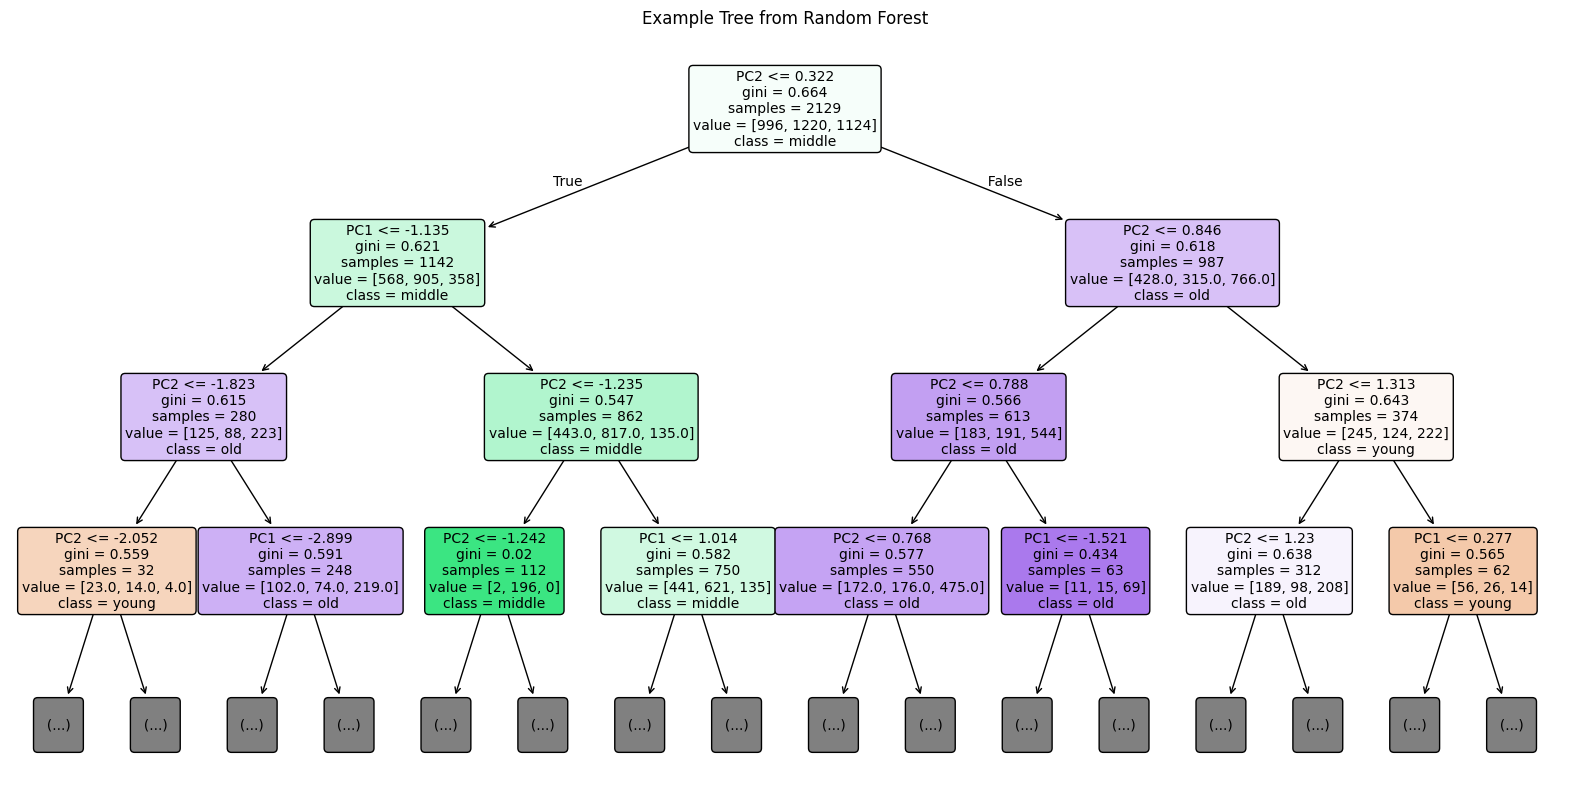

In [ ]:
#save the tree
#first select one tree of the hundred trees
one_tree = rfc_grouped.estimators_[0]
plt.figure(figsize=(20, 10))
plot_tree(one_tree, 
          feature_names=['PC1', 'PC2'],# without this we would see feature 0 as name in the nodes
          class_names=group_names,  # ['young', 'middle', 'old']
          filled=True, 
          rounded=True,
          max_depth=3,   # Limit depth to keep it readable
          fontsize=10)
plt.title("Example Tree from Random Forest")
plt.savefig("random_forest_tree.png", dpi=300, bbox_inches='tight')
plt.show()

## Deep Learning: The Manual Training Loop
Here we build a **Neural Network** (MLPClassifier). To understand how it learns, we use a manual loop instead of the automatic `.fit()` function.
**What happens in the code?**
1.  **Shuffle**: At the beginning of each "epoch" (round), we shuffle the data so the network doesn't memorize the order.
2.  **Mini-Batches**: We don't feed the network all 3000 animals at once, but rather small chunks (e.g., 32 at a time).
3.  **Partial Fit**: The network learns from these 32 examples (`partial_fit`), adjusts its weights, but doesn't forget what it learned before.
4.  **Epochs**: We repeat this 50 times until the error (Loss) is small enough.

In [ ]:
# 1. Prepare Data (Pandas -> Numpy & Text -> Numbers)
le = LabelEncoder()
y_train_num = le.fit_transform(y_train_c)  # Labels into 0, 1, 2
y_test_num = le.transform(y_test_c)
# Convert everything to Numpy arrays to allow slicing [0:32]
X_train_np = np.array(X_train_c)
y_train_np = np.array(y_train_num)
# 2. Setup
batch_size = 32
number_epochs = 50
all_classes = np.unique(y_train_num) # These are [0, 1, 2]
neural_net = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    batch_size=batch_size,
    random_state=42
)
# 3. The Loop
train_loss_history = []
for epoch in range(1, number_epochs + 1):
    epoch_losses = []  # Collect loss for this epoch
    
    # Shuffle data at the beginning of each epoch (Important for good learning!)
    permutation = np.random.permutation(len(y_train_np))
    X_shuffled = X_train_np[permutation]
    y_shuffled = y_train_np[permutation]
    
    # Inner Loop: Mini-Batches
    # range(start, stop, step):
    # start = 0 (We start with the first Abalone)
    # stop = len(y_train_np) (We stop when the data ends)
    # step = batch_size (e.g. 32). We jump in steps of 32: 0, 32, 64...
    # "i" is therefore always the START of our current batch.
    for i in range(0, len(y_train_np), batch_size):
        
        # Slicing [i : i+batch_size]:
        # We cut a piece out of the list.
        # "Take everything from index i (Start) to index i+32 (End)".
        # Example Round 1: i=0. We take [0:32] -> Abalone 0 to 31.
        # Example Round 2: i=32. We take [32:64] -> Abalone 32 to 63.
        X_batch = X_shuffled[i : i+batch_size]
        y_batch = y_shuffled[i : i+batch_size]
        
        # Train (partial_fit)
        # IMPORTANT: 'classes' must contain ALL possible classes!
        neural_net.partial_fit(X_batch, y_batch, classes=all_classes)
        
        # Save loss (if available)
        # (At the beginning loss_ might not be available yet, so try/except or check)
        if hasattr(neural_net, 'loss_'):
            epoch_losses.append(neural_net.loss_)
    # Print average loss of the epoch
    if epoch_losses:
        avg_loss = np.mean(epoch_losses)
        train_loss_history.append(avg_loss)
        if epoch % 10 == 0: # Print only every 10 epochs (to keep it clear)
            print(f'Epoch {epoch:02d} | Loss: {avg_loss:.4f}')
# 4. Result
print("\nTraining finished!")
print("Test Accuracy:", accuracy_score(y_test_num, neural_net.predict(X_test_c)))


Epoch 10 | Loss: 0.6421
Epoch 20 | Loss: 0.4938
Epoch 30 | Loss: 0.3639
Epoch 40 | Loss: 0.2795
Epoch 50 | Loss: 0.2436

Training finished!
Test Accuracy: 0.9245508982035928


In [33]:
# 1. Input X (Our PCA Data) (no drop because we did PCA and strictly speaking no Sex column exists)
X = abalone_pca_sklearn 
# 2. Target y (Take Sex column directly, as it is already numbers 0,1,2)
y_sex = abalone['Sex']
# 3. Split
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y_sex, test_size=0.2, random_state=42)
print("PCA Train shape:", X_train_s.shape)
print("Test shape:", y_train_s.shape)

PCA Train shape: (3340, 2)
Test shape: (3340,)


When you write X_train_s[0:32], Pandas often thinks you mean you mean index names ("Find the row named '0'") and not the position ("Give me the first row").
If we did train_test_split before, the indices are jumbled (e.g., row 1 has index 452, row 2 has index 12).
A loop [0:32] would then crash because there are no indices 0 to 32 anymore.

In [34]:
# 1. Convert data to Numpy (The Gender Set!)
X_train_np = np.array(X_train_s)
y_train_np = np.array(y_train_s)
# 2. Setup
batch_size = 32
number_epochs = 50
all_classes = np.unique(y_train_np) # [0, 1, 2]
neural_net = MLPClassifier(
    hidden_layer_sizes=(64, 32), 
    activation='relu', 
    batch_size=batch_size,
    random_state=42
)
# 3. The Loop
train_loss_history = []
for epoch in range(1, number_epochs + 1):
    epoch_losses = [] 
    
    # Shuffle (with the Gender data!)
    permutation = np.random.permutation(len(y_train_np))
    X_shuffled = X_train_np[permutation]
    y_shuffled = y_train_np[permutation]
    
    # Inner Loop
    for i in range(0, len(y_train_np), batch_size):
        X_batch = X_shuffled[i : i+batch_size]
        y_batch = y_shuffled[i : i+batch_size]
        
        neural_net.partial_fit(X_batch, y_batch, classes=all_classes)
        
        if hasattr(neural_net, 'loss_'):
            epoch_losses.append(neural_net.loss_)
            
    if epoch_losses:
        avg_loss = np.mean(epoch_losses)
        train_loss_history.append(avg_loss)
        if epoch % 10 == 0: 
            print(f'Epoch {epoch:02d} | Loss: {avg_loss:.4f}')
# 4. Result
print("\nTraining finished!")
# -- STEP A: Make Predictions --
# We let the model run twice:
# 1. The "Exam" (Test Data):
# These are data the model has NEVER seen before. 
# Shows if it really understood (Generalization).
y_pred_sex = neural_net.predict(X_test_s)
# 2. The "Homework Check" (Training Data):
# These are the data it has already practiced 50 times.
# Shows if it just memorized the solutions.
train_pred = neural_net.predict(X_train_s)
# -- STEP B: Compare Grades --
print("--- Overfitting Check ---")
# Here we compare: Is it much better at homework (training) than in the exam (test)?
# If yes -> Overfitting (Memorization).
# If no (similar values) -> All good!
print(f"Training Accuracy  {accuracy_score(y_train_s, train_pred):.2%}")
print(f"Test Accuracy :    {accuracy_score(y_test_s, y_pred_sex):.2%}")
print("-" * 30)
# -- STEP C: The Detailed Report --
# Breaks down how well Male, Female, and Infant were recognized.
print(classification_report(y_test_s, y_pred_sex, target_names=["M", "F", "I"]))

Epoch 10 | Loss: 0.2314
Epoch 20 | Loss: 0.2213
Epoch 30 | Loss: 0.2205
Epoch 40 | Loss: 0.2170
Epoch 50 | Loss: 0.2199

Training finished!
--- Overfitting Check ---
Training Accuracy  92.28%
Test Accuracy :    92.69%
------------------------------
              precision    recall  f1-score   support

           M       0.86      0.98      0.92       299
           F       0.95      0.82      0.88       272
           I       1.00      0.98      0.99       264

    accuracy                           0.93       835
   macro avg       0.93      0.93      0.93       835
weighted avg       0.93      0.93      0.93       835



In [35]:
# We pick ONE random Abalone from the test data
import random
# We do this 5 times (loop)
for i in range(5):
    # 1. We roll a row number (e.g., "Row 500")
    random_index = random.randint(0, len(X_test_s) - 1)
    # 2. ACCESS THE QUESTION (X)
    # X_test_s is our large Numpy table with the PCA values.
    # [random_index] grabs exactly THAT ONE row (e.g., [1.5, -0.3]).
    # .reshape(1, -1) packs it into an extra box [[...]] so Sklearn doesn't complain.
    sample_data = X_test_s[random_index].reshape(1, -1)
    # 3. ACCESS THE ANSWER (y)
    # y_test_s is our list with the solutions (0, 1, 2).
    # .iloc[random_index] ("Integer Location") grabs the element at position "random_index".
    true_gender_code = y_test_s.iloc[random_index]
    # 4. The model is asked
    # We feed the question (sample_data) into the net.
    # [0] gets the number from the result list (e.g., [0] -> 0).
    prediction_code = neural_net.predict(sample_data)[0]
    # 5. Translation & Output
    gender_map = {0: "Male", 1: "Female", 2: "Infant"}
    
    print(f"--- Abalone Row {random_index} ---")
    print(f"Model guesses: {gender_map[prediction_code]}")
    print(f"Real solution: {gender_map[true_gender_code]}")
    if prediction_code == true_gender_code:
        print("✅ Correct!")
    else:
        print("❌ Wrong!")
    print("-" * 20) # Separator

--- Abalone Row 369 ---
Model guesses: Female
Real solution: Female
✅ Correct!
--------------------
--- Abalone Row 237 ---
Model guesses: Infant
Real solution: Infant
✅ Correct!
--------------------
--- Abalone Row 91 ---
Model guesses: Infant
Real solution: Infant
✅ Correct!
--------------------
--- Abalone Row 129 ---
Model guesses: Infant
Real solution: Infant
✅ Correct!
--------------------
--- Abalone Row 645 ---
Model guesses: Infant
Real solution: Infant
✅ Correct!
--------------------


In [36]:
# 1. Known Data (Training)
train_pred = neural_net.predict(X_train_s)
train_acc = accuracy_score(y_train_s, train_pred)
# 2. Unknown Data (Test)
test_pred = neural_net.predict(X_test_s)
test_acc = accuracy_score(y_test_s, test_pred)
print(f"Training Accuracy: {train_acc:.2%}")
print(f"Test Accuracy:     {test_acc:.2%}")
diff = train_acc - test_acc
if diff > 0.10: # More than 10% difference?
    print("⚠️ Warning: Suspected Overfitting!")
else:
    print("✅ All good. No strong overfitting.")

Training Accuracy: 92.28%
Test Accuracy:     92.69%
✅ All good. No strong overfitting.
